In [15]:
import os
import numpy as np
import seaborn as sns
from configs import ModelConfig
import matplotlib.pyplot as plt

In [34]:
model = 'densenet101'
in_dataset = 'CIFAR-100'
# out_dataset = 'dtd'

# model = 'resnet_imagenet34'
# in_dataset = 'ImageNet-1K'
# out_dataset = 'Places'

In [35]:
base_directory_name = f"{model}/{in_dataset}/"
model_checkpoint_directory = os.path.join(ModelConfig.model_checkpoint_directory, base_directory_name)
model_statistics_directory = os.path.join(ModelConfig.model_statistics_directory, base_directory_name)
print(model_statistics_directory)

in_model_statistics_directory = os.path.join(model_statistics_directory, f"{in_dataset}")
in_statistics_file_name = os.path.join(in_model_statistics_directory, f"in_{in_dataset}")
print(in_statistics_file_name)

in_avg_logit_fname = in_statistics_file_name + '_avg_logit.npy'
in_avg_logit = np.load(in_avg_logit_fname)
print(in_avg_logit.shape)

in_max_logit_fname = in_statistics_file_name + '_max_logit.npy'
in_max_logit = np.load(in_max_logit_fname)
print(in_max_logit.shape)

/Users/abidhassan/Desktop/DomAct/models/statistics/densenet101/CIFAR-100/
/Users/abidhassan/Desktop/DomAct/models/statistics/densenet101/CIFAR-100/CIFAR-100/in_CIFAR-100
(10000, 100)
(10000, 100)


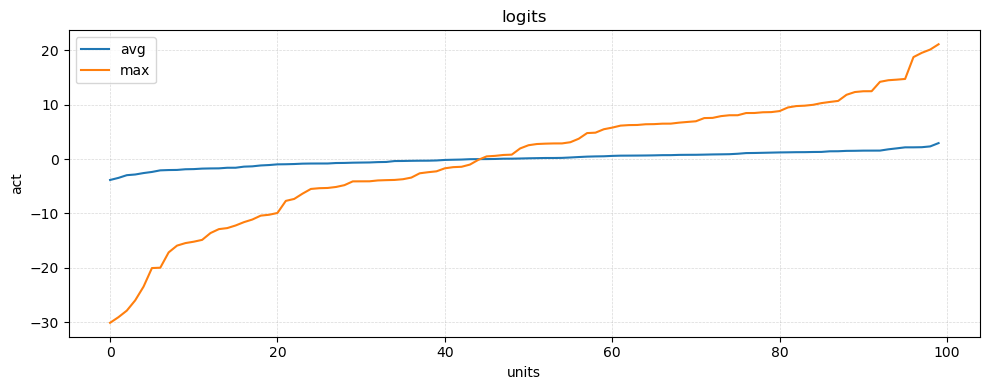

In [36]:
in_avg_logit_mean = in_avg_logit.mean(0)
in_max_logit_mean = in_max_logit.mean(0)
in_avg_logit_mean.sort()
in_max_logit_mean.sort()

plt.figure(figsize=(10, 4))
plt.plot(in_avg_logit_mean, label='avg')
plt.plot(in_max_logit_mean, label='max')


plt.title('logits')
plt.xlabel('units')
plt.ylabel('act')
plt.legend(loc = 'best')
plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
out_model_statistics_directory = os.path.join(model_statistics_directory, f"{out_dataset}")
out_statistics_file_name = os.path.join(out_model_statistics_directory, f"out_{out_dataset}")
print(out_statistics_file_name)

out_logit_fname = out_statistics_file_name + '_avg_logit.npy'
out_logit = np.load(out_logit_fname)
out_logit.shape

/Users/abidhassan/Desktop/DomAct/models/statistics/resnet18/CIFAR-10/dtd/out_dtd


(5640, 10)

In [14]:
in_logit_mean = in_logit.mean(0)
out_logit_mean = out_logit.mean(0)

NameError: name 'in_logit' is not defined

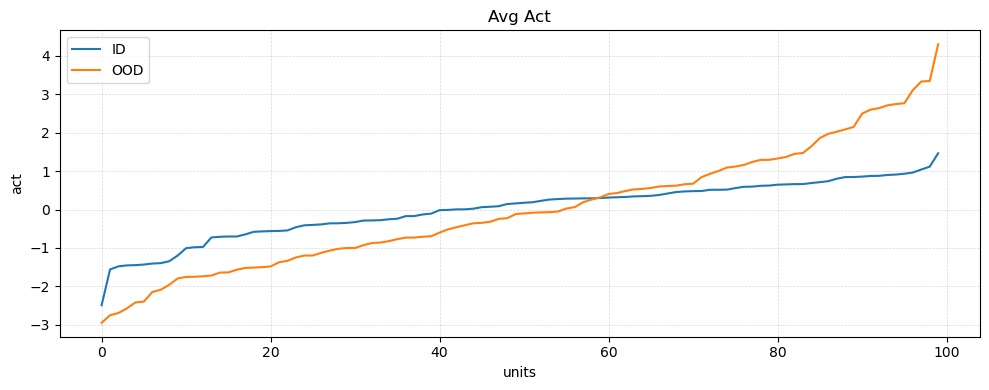

In [20]:
in_logit_mean.sort()
out_logit_mean.sort()

plt.figure(figsize=(10, 4))
plt.plot(in_logit_mean, label='ID')
plt.plot(out_logit_mean, label='OOD')


plt.title('Avg Act')
plt.xlabel('units')
plt.ylabel('act')
plt.legend(loc = 'best')
plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()

plt.show()